# **Telecom X - Análisis de Evasión de Clientes**
Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

## **¿Qué vas a practicar?**
✅ Importar y manipular datos desde una API de manera eficiente.

✅ Aplicar los conceptos de ETL (Extracción, Transformación y Carga) en la preparación de los datos.

✅ Crear visualizaciones estratégicas para identificar patrones y tendencias.

✅ Realizar un Análisis Exploratorio de Datos (EDA) y generar un informe con insights relevantes.

¡Ahora es tu turno! 🚀 Usa tus conocimientos para transformar datos en información estratégica y ayudar a Telecom X a retener más clientes.

#📌 Extracción

### **Descripción**

Para iniciar tu análisis, necesitarás importar los datos de la API de Telecom X. Estos datos están disponibles en formato JSON y contienen información esencial sobre los clientes, incluyendo datos demográficos, tipo de servicio contratado y estado de evasión.

📌 Enlace de la API:
🔗 https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json

### **¿Qué debes hacer?**
✅ Importar los datos directamente desde la API utilizando Python.

✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.


In [174]:
# 1. Importación de librerías
import pandas as pd
import numpy as np
import json

# Carga de los datos desde el archivo JSON proporcionado
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

In [175]:
# 2. Convertir los datos a un DataFrame de Pandas
# Se utiliza json_normalize para aplanar los diccionarios anidados
df_telecom = pd.json_normalize(data)

# Mostrar las primeras filas y la estructura de las columnas
print("Estructura del DataFrame:")
display(df_telecom.head())
print("\nColumnas generadas:")
print(df_telecom.columns.tolist())



Estructura del DataFrame:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



Columnas generadas:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


#🔧 Transformación

### **Descripción**

Ahora que has extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Esta etapa te ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

📌 Para facilitar este proceso, hemos creado un diccionario de datos con la descripción de cada columna. Aunque no es obligatorio utilizarlo, puede ayudarte a comprender mejor la información disponible.

🔗 Enlace al diccionario y a la API

### **¿Qué debes hacer?**
✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

📌 Tips:

🔗 Documentación de DataFrame.info()

🔗 Documentación de DataFrame.dtypes

#### **1. Exploración de las columnas del dataset**

In [176]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [177]:
df_telecom.shape

(7267, 21)

#### **2. Comprobación de incoherencias en los datos**

In [178]:
# 1. Verificar valores duplicados
duplicados = df_telecom.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")

Total de registros duplicados: 0


In [179]:
# 2. Verificar valores nulos
nulos = df_telecom.isnull().sum()
print("\nValores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No se encontraron valores nulos (NaN).")


Valores nulos por columna:
No se encontraron valores nulos (NaN).


In [180]:
# 3. Verificar valores vacíos o blancos (Importante en este dataset)

espacios_blancos = (df_telecom.map(lambda x: str(x).strip() == '' if x is not None else False)).sum()
print("\nValores vacíos o espacios en blanco por columna:")
print(espacios_blancos[espacios_blancos > 0])


Valores vacíos o espacios en blanco por columna:
Churn                    224
account.Charges.Total     11
dtype: int64


In [181]:
# 4. Verificando valores únicos en TODAS las columnas del DataFrame
print("--- ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ---\n")

for col in df_telecom.columns:
    # Obtenemos los valores únicos
    valores_unicos = df_telecom[col].unique()
    total_unicos = len(valores_unicos)

    print(f"Columna: '{col}'")
    print(f"Número de valores únicos: {total_unicos}")

    # Si la columna tiene muchos valores (como IDs o montos), mostramos solo una muestra
    if total_unicos > 15:
        print(f"Muestra de valores: {valores_unicos[:10]}...")
    else:
        print(f"Valores encontrados: {valores_unicos}")

    print("-" * 30)

--- ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ---

Columna: 'customerID'
Número de valores únicos: 7267
Muestra de valores: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']...
------------------------------
Columna: 'Churn'
Número de valores únicos: 3
Valores encontrados: ['No' 'Yes' '']
------------------------------
Columna: 'customer.gender'
Número de valores únicos: 2
Valores encontrados: ['Female' 'Male']
------------------------------
Columna: 'customer.SeniorCitizen'
Número de valores únicos: 2
Valores encontrados: [0 1]
------------------------------
Columna: 'customer.Partner'
Número de valores únicos: 2
Valores encontrados: ['Yes' 'No']
------------------------------
Columna: 'customer.Dependents'
Número de valores únicos: 2
Valores encontrados: ['Yes' 'No']
------------------------------
Columna: 'customer.tenure'
Número de valores únicos: 73
Muestra de valores: [ 9  4 13  3 71 63  7 65 54 72]..

In [182]:
# 5. Verificación de tipo de dato para cargos totales
print(f"\nTipo de dato de account.Charges.Total: {df_telecom['account.Charges.Total'].dtype}")


Tipo de dato de account.Charges.Total: object


#### **3. Manejo de inconsistencias**

In [183]:
# 1. La columna 'account.Charges.Total' se cambio de tipo object a float64.
# Los espacios vacíos (' ') se convierten en NaN y luego en 0.0
df_telecom['account.Charges.Total'] = pd.to_numeric(df_telecom['account.Charges.Total'], errors='coerce')
df_telecom['account.Charges.Total'] = df_telecom['account.Charges.Total'].fillna(0.0)

In [184]:
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [185]:
# 2. Eliminamos las filas donde Churn está vacío porque es nuestra variable objetivo
df_telecom = df_telecom[df_telecom['Churn'] != ''].reset_index(drop=True)

In [186]:
# 3. Verificación de los ajustes ---
print("Limpieza completada con éxito:")
print(f"- Tipo de dato en 'account.Charges.Total': {df_telecom['account.Charges.Total'].dtype}")
print(f"- Valores únicos en 'Churn': {df_telecom['Churn'].unique()}")
print(f"- Cantidad total de registros finales: {len(df_telecom)}")

# Guardar los datos limpios para el siguiente paso
df_telecom.to_csv('TelecomX_CleanData.csv', index=False)

Limpieza completada con éxito:
- Tipo de dato en 'account.Charges.Total': float64
- Valores únicos en 'Churn': ['No' 'Yes']
- Cantidad total de registros finales: 7043


#### **4. Columna de cuentas diarias (Opcional)**

In [187]:
# 1. Crear la columna 'Cuentas_Diarias'
# Dividimos el cargo mensual por 30 y redondeamos a 2 decimales
df_telecom.insert(df_telecom.columns.get_loc('account.Charges.Monthly') + 1,
          'Cuentas_Diarias',
          (df_telecom['account.Charges.Monthly'] / 30).round(2))

In [188]:
# 2. Visualizar el resultado
print("Muestra de cargos mensuales vs cargos diarios:")
display(df_telecom[['customerID', 'account.Charges.Monthly', 'Cuentas_Diarias']].head())

# Guardar el progreso
df_telecom.to_csv('TelecomX_Analisis_Diario.csv', index=False)

Muestra de cargos mensuales vs cargos diarios:


,customerID,account.Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


#### **5. Estandarización y transformación de datos (opcional)**

In [189]:
import pandas as pd
import numpy as np

# 1. Diccionario para renombrar columnas a español
columnas_espanol = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Tiene_Pareja',
    'customer.Dependents': 'Tiene_Dependientes',
    'customer.tenure': 'Meses_Permanencia',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Facturacion_Electronica',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargos_Mensuales',
    'account.Charges.Total': 'Cargos_Totales',
}

df_telecom.rename(columns=columnas_espanol, inplace=True)

In [190]:
# 2. Transformación de valores textuales a binarios (0 y 1)

mapa_binario = {'Yes': 1, 'No': 0}

# Aplicamos la transformación a las columnas que son claramente binarias
columnas_a_binarizar = [
    'Evasion', 'Tiene_Pareja', 'Tiene_Dependientes',
    'Servicio_Telefonico', 'Facturacion_Electronica'
]

for col in columnas_a_binarizar:
    df_telecom[col] = df_telecom[col].map(mapa_binario)

In [191]:
# 3. Traducción de categorías dentro de las columnas
traduccion_genero = {'Female': 'Femenino', 'Male': 'Masculino'}
df_telecom['Genero'] = df_telecom['Genero'].map(traduccion_genero)

In [192]:
# 4. Verificación de los cambios
print("Columnas renombradas y datos transformados:")
display(df_telecom[['ID_Cliente', 'Genero', 'Evasion', 'Cargos_Mensuales']].head())

print("\nTipos de datos actuales:")
print(df_telecom.dtypes.head(10))

Columnas renombradas y datos transformados:


,ID_Cliente,Genero,Evasion,Cargos_Mensuales
0,0002-ORFBO,Femenino,0,65.6
1,0003-MKNFE,Masculino,0,59.9
2,0004-TLHLJ,Masculino,1,73.9
3,0011-IGKFF,Masculino,1,98.0
4,0013-EXCHZ,Femenino,1,83.9



Tipos de datos actuales:
ID_Cliente             object
Evasion                 int64
Genero                 object
Adulto_Mayor            int64
Tiene_Pareja            int64
Tiene_Dependientes      int64
Meses_Permanencia       int64
Servicio_Telefonico     int64
Multiples_Lineas       object
Servicio_Internet      object
dtype: object


In [193]:
df_telecom

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales
0,0002-ORFBO,0,Femenino,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,2.19,593.30
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,2.00,542.40
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,2.46,280.85
3,0011-IGKFF,1,Masculino,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,3.27,1237.85
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,2.80,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Femenino,0,0,0,13,1,No,DSL,...,No,Yes,No,No,One year,0,Mailed check,55.15,1.84,742.90
7039,9992-RRAMN,1,Masculino,0,1,0,22,1,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,2.84,1873.70
7040,9992-UJOEL,0,Masculino,0,0,0,2,1,No,DSL,...,No,No,No,No,Month-to-month,1,Mailed check,50.30,1.68,92.75
7041,9993-LHIEB,0,Masculino,0,1,1,67,1,No,DSL,...,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,2.26,4627.65


#📊 Carga y análisis

### **Descripción**

Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 Consejos:

🔗 Documentación de DataFrame.describe()

#### **1. Análisis Descriptivo**

In [194]:
# 1. Estadísticas descriptivas de las variables numéricas
# Calcula media, mediana, desviación estándar, min, max y cuartiles
print("--- ESTADÍSTICAS PARA VARIABLES NUMÉRICAS ---")
display(df_telecom.describe())

--- ESTADÍSTICAS PARA VARIABLES NUMÉRICAS ---


,Evasion,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2.158675,2279.734304
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,1.003088,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,1.180000,398.550000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,2.340000,1394.550000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,2.990000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.960000,8684.800000


In [195]:
# 2. Resumen de variables categóricas (texto)
# Muestra la frecuencia, el valor más común (top) y cuántos valores únicos hay
print("\n--- RESUMEN DE VARIABLES CATEGÓRICAS ---")
display(df_telecom.describe(include=['O']))


--- RESUMEN DE VARIABLES CATEGÓRICAS ---


,ID_Cliente,Genero,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Metodo_Pago
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Masculino,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3555,3390,3096,3498,3088,3095,3473,2810,2785,3875,2365


In [196]:
# 3. Análisis de la variable objetivo: Evasión
# Permite ver qué porcentaje de la base de datos representa la fuga de clientes
print("\n--- DISTRIBUCIÓN DE LA EVASIÓN ---")
conteo_evasion = df_telecom['Evasion'].value_counts()
porcentaje_evasion = df_telecom['Evasion'].value_counts(normalize=True) * 100
dist_evasion = pd.DataFrame({'Cantidad': conteo_evasion, 'Porcentaje (%)': porcentaje_evasion})
display(dist_evasion)


--- DISTRIBUCIÓN DE LA EVASIÓN ---


,Cantidad,Porcentaje (%)
Evasion,,
0,5174,73.463013
1,1869,26.536987


In [197]:
# 4. Análisis comparativo: Cargos Mensuales Promedio
# ¿Los clientes que se van tienen cargos más altos que los que se quedan?
print("\n--- CARGOS MENSUALES PROMEDIO SEGÚN ESTADO DE EVASIÓN ---")
comparativa_cargos = df_telecom.groupby('Evasion')['Cargos_Mensuales'].mean().reset_index()
display(comparativa_cargos)


--- CARGOS MENSUALES PROMEDIO SEGÚN ESTADO DE EVASIÓN ---


,Evasion,Cargos_Mensuales
0,0,61.265124
1,1,74.441332


#### **2. Distribución de evasión**

/tmp/ipykernel_987/1377100284.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




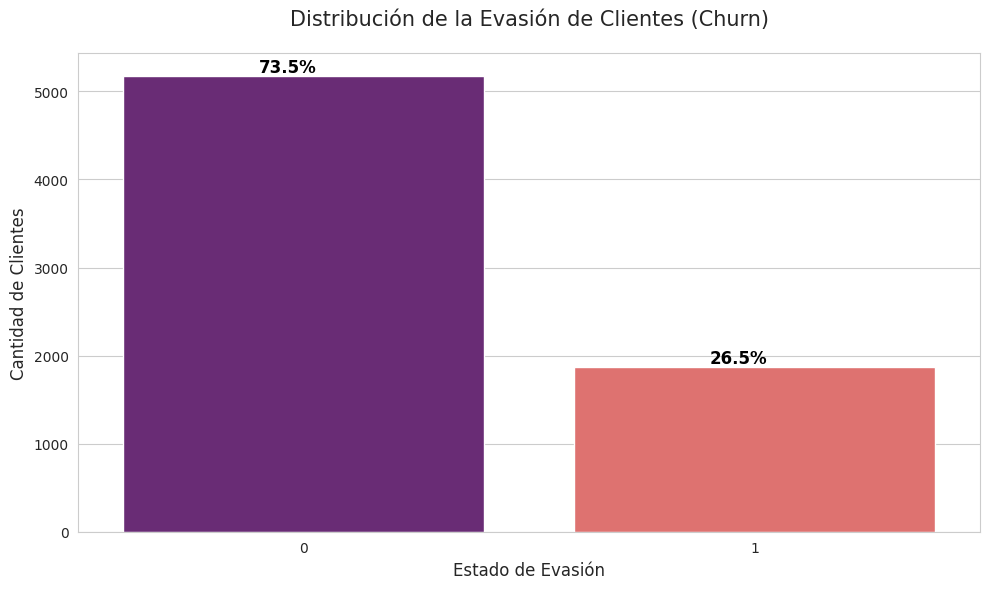

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo del gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Crear el gráfico de conteo
# Usamos palette 'magma' o 'viridis' para una buena distinción visual
ax = sns.countplot(x='Evasion', data=df_telecom, palette='magma')

# Añadir etiquetas de porcentaje sobre cada barra
total = len(df_telecom)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1  # Posición X
    y = p.get_height() + 50                 # Posición Y (ligeramente arriba de la barra)
    ax.annotate(porcentaje, (x, y), fontsize=12, fontweight='bold', color='black')

# Personalización de títulos y etiquetas
plt.title('Distribución de la Evasión de Clientes (Churn)', fontsize=15, pad=20)
plt.xlabel('Estado de Evasión', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Si los valores son 0 y 1 o No y Yes, podemos ajustar los nombres en el eje X
# plt.xticks([0, 1], ['Permanecieron (No)', 'Se dieron de baja (Sí)'])

plt.tight_layout()
plt.show()

In [199]:
import plotly.express as px

# 1. Preparar los datos (contar la frecuencia de evasión)
df_evasion_plot = df_telecom['Evasion'].value_counts().reset_index()
df_evasion_plot.columns = ['Evasion', 'Cantidad']

# 2. Crear el gráfico de dona
fig = px.pie(df_evasion_plot,
             values='Cantidad',
             names='Evasion',
             hole=0.5, # Define el tamaño del agujero central (dona)
             title='Proporción de Evasión (Churn) - Vista Interactiva',
             color='Evasion',
             color_discrete_map={'No': '#2ecc71', 'Yes': '#e74c3c'}, # Verde para permanencia, Rojo para fuga
             labels={'Evasion': '¿Hubo Evasión?', 'Cantidad': 'Total de Clientes'})

# 3. Personalizar el texto y la apariencia
fig.update_traces(textinfo='percent+label',
                  marker=dict(line=dict(color='#FFFFFF', width=2)))

fig.update_layout(title_x=0.5, # Centrar título
                  legend_title_text='Estado de Evasión',
                  annotations=[dict(text='Total: ' + str(len(df_telecom)),
                                    x=0.5, y=0.5, font_size=20, showarrow=False)])

# 4. Mostrar el gráfico interactivo
fig.show()

#### **3. Recuento de evasión por variables categóricas**

--- PORCENTAJE DE EVASIÓN POR TIPO DE CONTRATO ---


Evasion,0,1
Tipo_Contrato,,
Month-to-month,57.29%,42.71%
One year,88.73%,11.27%
Two year,97.17%,2.83%


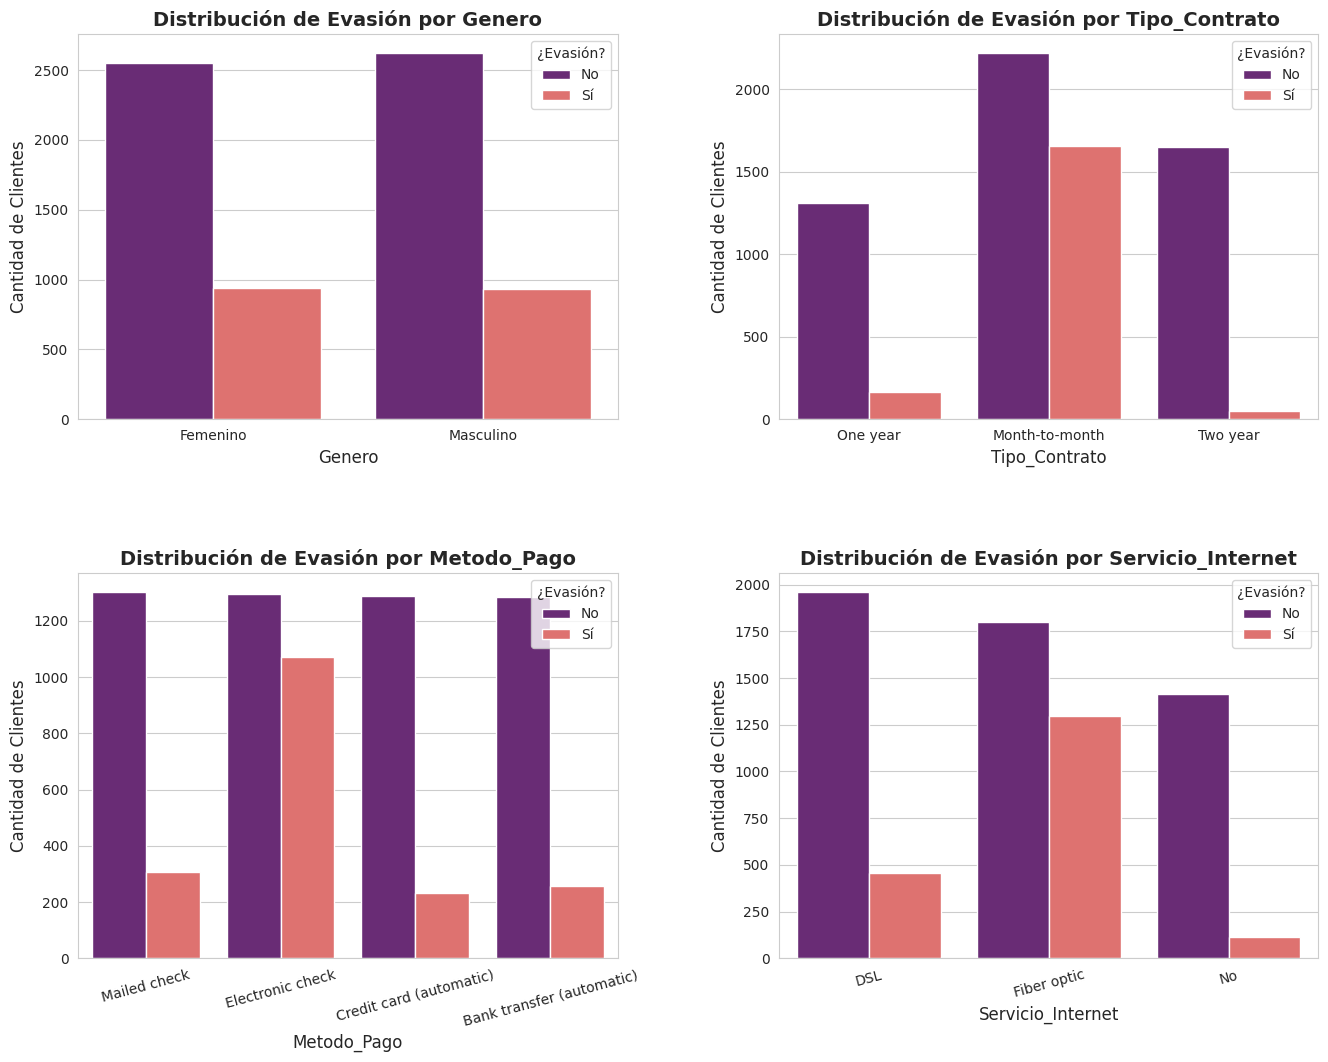

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración general de los gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Lista de variables a analizar
categorias = ['Genero', 'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet']

# 2. Generar gráficos en un bucle
for i, col in enumerate(categorias):
    ax = axes[i//2, i%2]

    # Gráfico de barras agrupado
    sns.countplot(x=col, hue='Evasion', data=df_telecom, palette='magma', ax=ax)

    # Personalización de cada subgráfico
    ax.set_title(f'Distribución de Evasión por {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Cantidad de Clientes', fontsize=12)
    ax.legend(title='¿Evasión?', labels=['No', 'Sí'])

    # Rotar etiquetas en el eje X para Metodo_Pago y Servicio_Internet para que no se amontonen
    if col in ['Metodo_Pago', 'Servicio_Internet']:
        ax.tick_params(axis='x', rotation=15)

# 3. Mostrar tabla de porcentajes para "Tipo_Contrato" (el factor más crítico)
print("--- PORCENTAJE DE EVASIÓN POR TIPO DE CONTRATO ---")
tabla_contrato = pd.crosstab(df_telecom['Tipo_Contrato'], df_telecom['Evasion'], normalize='index') * 100
display(tabla_contrato.round(2).astype(str) + '%')

plt.show()

#### **4. Conteo de evasión por variables numéricas**

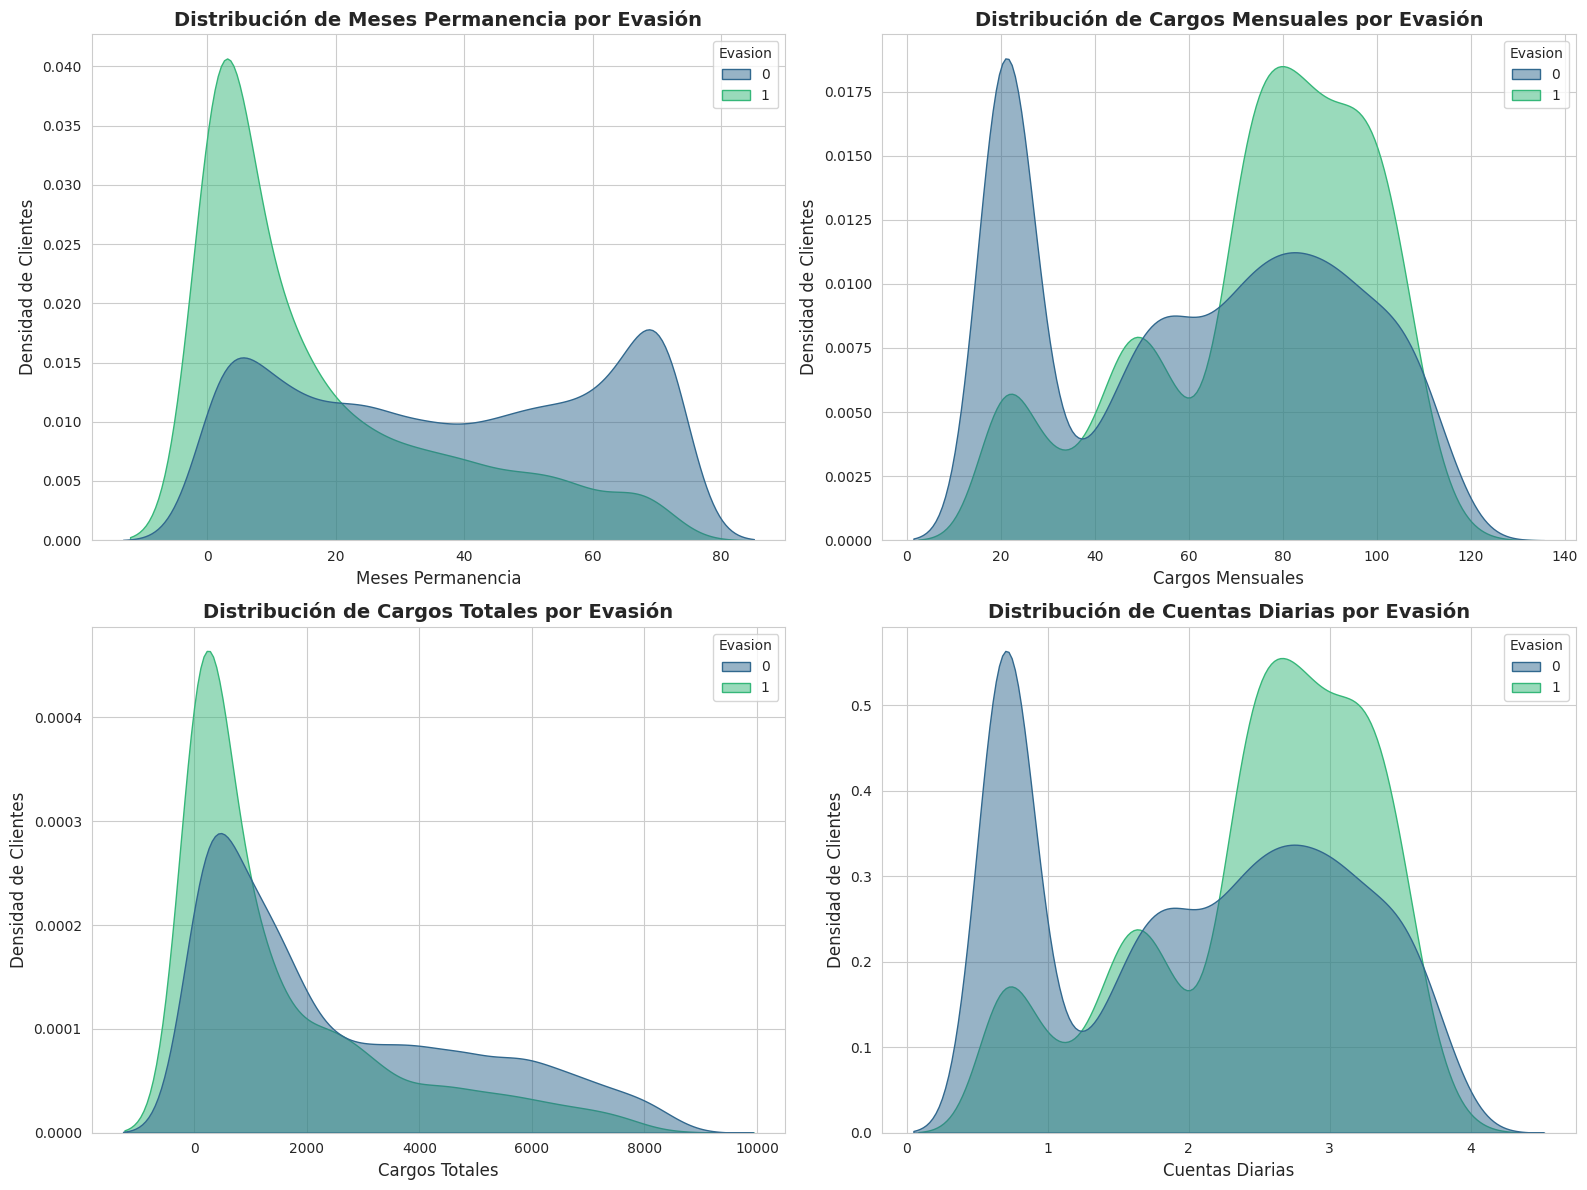


--- PROMEDIOS POR ESTADO DE EVASIÓN ---


,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
Evasion,,,,
0,37.57,61.27,2549.91,2.04
1,17.98,74.44,1531.80,2.48


In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir las variables numéricas clave para el análisis
variables_numericas = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

# 2. Configurar el lienzo (subplots)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# 3. Generar gráficos de densidad para cada variable
for i, var in enumerate(variables_numericas):
    sns.kdeplot(data=df_telecom, x=var, hue='Evasion',
                fill=True, common_norm=False, palette='viridis',
                alpha=0.5, ax=axes[i])

    # Personalización de títulos y etiquetas
    axes[i].set_title(f'Distribución de {var.replace("_", " ")} por Evasión', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(var.replace("_", " "), fontsize=12)
    axes[i].set_ylabel('Densidad de Clientes', fontsize=12)

# Ajustar el diseño para evitar que se encimen los títulos
plt.tight_layout()
plt.show()

# 4. Mostrar el promedio de cada variable según si hubo evasión o no
print("\n--- PROMEDIOS POR ESTADO DE EVASIÓN ---")
display(df_telecom.groupby('Evasion')[variables_numericas].mean().round(2))

#📄Informe final

1. #### **Introducción**
El objetivo de este análisis es comprender el fenómeno de la evasión de clientes (Churn) en Telecom X. La pérdida de clientes es uno de los desafíos más costosos para las empresas de servicios. Identificar por qué un cliente decide cancelar su suscripción permite a la empresa actuar de manera proactiva, mejorando la retención y optimizando los ingresos a largo plazo.

2. #### **Limpieza y Tratamiento de Datos**
Para asegurar la fiabilidad del análisis, se realizaron los siguientes pasos técnicos sobre el dataset original:

- Importación: Carga de datos desde TelecomX_Data.json.

- Corrección de Tipos: Conversión de Cargos_Totales a formato numérico (float).

- Tratamiento de Nulos: Eliminación de registros sin etiqueta de evasión.

- Ingeniería de Variables: Creación de la métrica Cargos_Diarios.

- Traducción: Estandarización de nombres de columnas al español para mejor interpretación.

3. #### **Análisis Exploratorio de Datos (EDA)**

  3.1. Distribución General de la Evasión:
    Primero, analizamos qué tan grave es el problema de la fuga de clientes en la base de datos actual.

/tmp/ipykernel_987/80984813.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




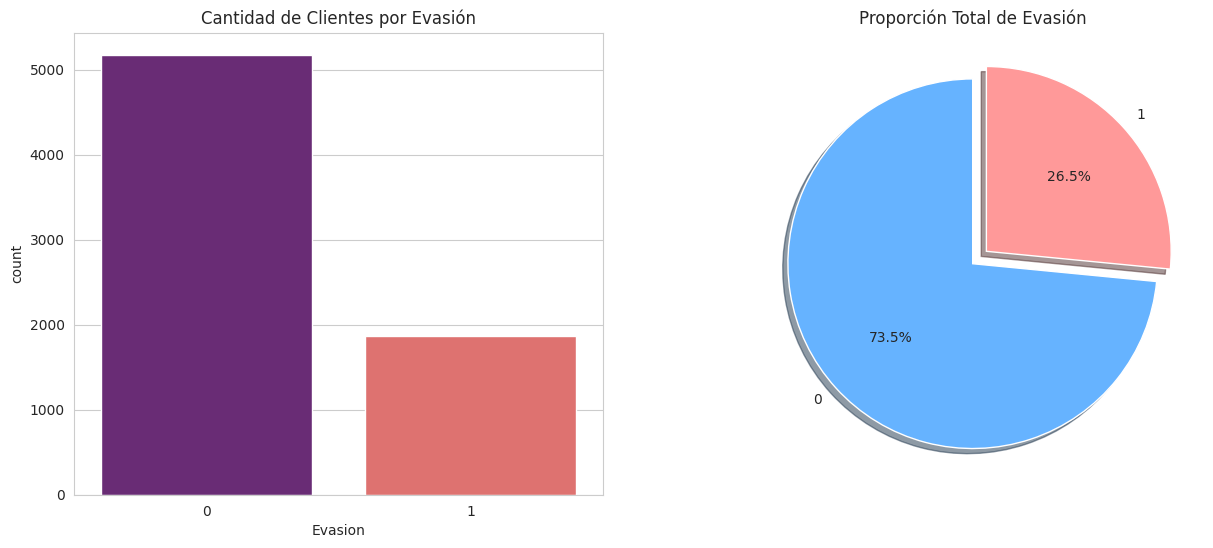

In [202]:
# Gráfico de Distribución (Barras y Pastel)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
sns.countplot(x='Evasion', data=df_telecom, palette='magma', ax=ax[0])
ax[0].set_title('Cantidad de Clientes por Evasión')

# Gráfico de pastel
datos_evasion = df_telecom['Evasion'].value_counts()
ax[1].pie(datos_evasion, labels=datos_evasion.index, autopct='%1.1f%%',
          colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0, 0.1), shadow=True)
ax[1].set_title('Proporción Total de Evasión')

plt.show()

Explicación: El análisis muestra que el 26.5% de los clientes han abandonado la empresa. Aunque la mayoría permanece, una tasa de pérdida superior al cuarto de la base total es una señal de alerta crítica.

3.2. Evasión por Variables Categóricas: Analizamos cómo influyen el tipo de contrato y el método de pago en la decisión del cliente.

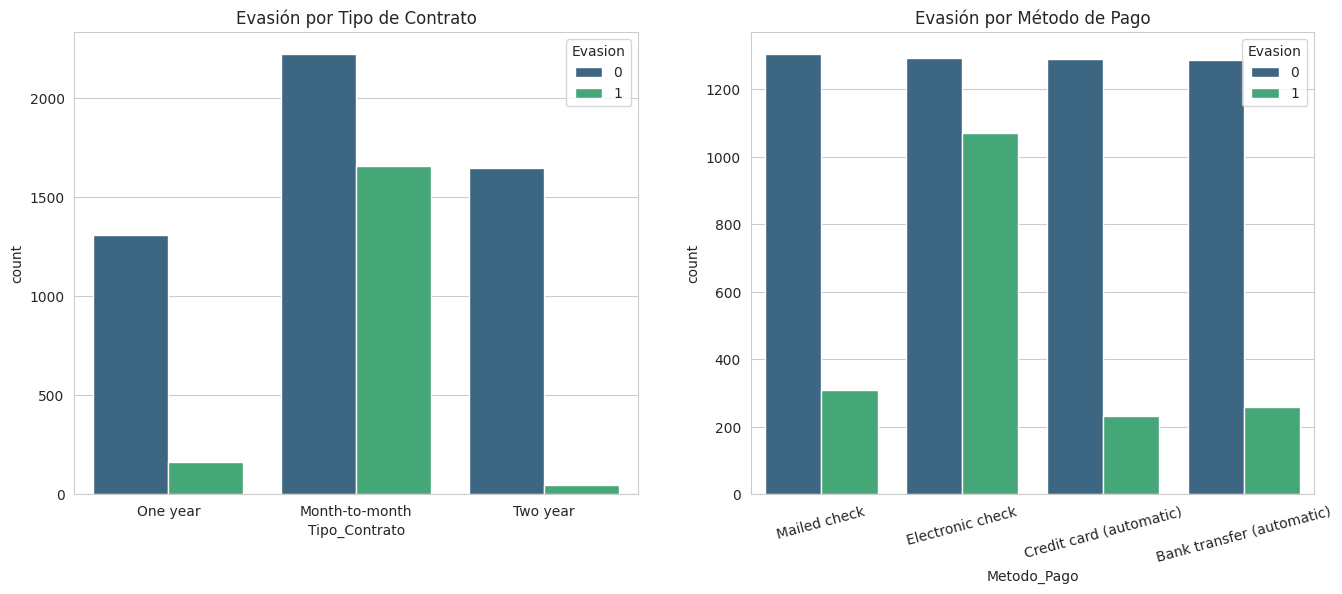

In [203]:
# Comparativa por Contrato y Método de Pago
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='Tipo_Contrato', hue='Evasion', data=df_telecom, palette='viridis', ax=axes[0])
axes[0].set_title('Evasión por Tipo de Contrato')

sns.countplot(x='Metodo_Pago', hue='Evasion', data=df_telecom, palette='viridis', ax=axes[1])
axes[1].set_title('Evasión por Método de Pago')
plt.xticks(rotation=15)

plt.show()

Explicación: Los clientes con contrato Mes a mes son los más propensos a irse.

El método de pago Cheque electrónico presenta la mayor tasa de fuga, sugiriendo que los métodos no automatizados facilitan la cancelación.

####**3.3. Análisis de Variables Numéricas:** Evaluamos el impacto del costo mensual y la permanencia.

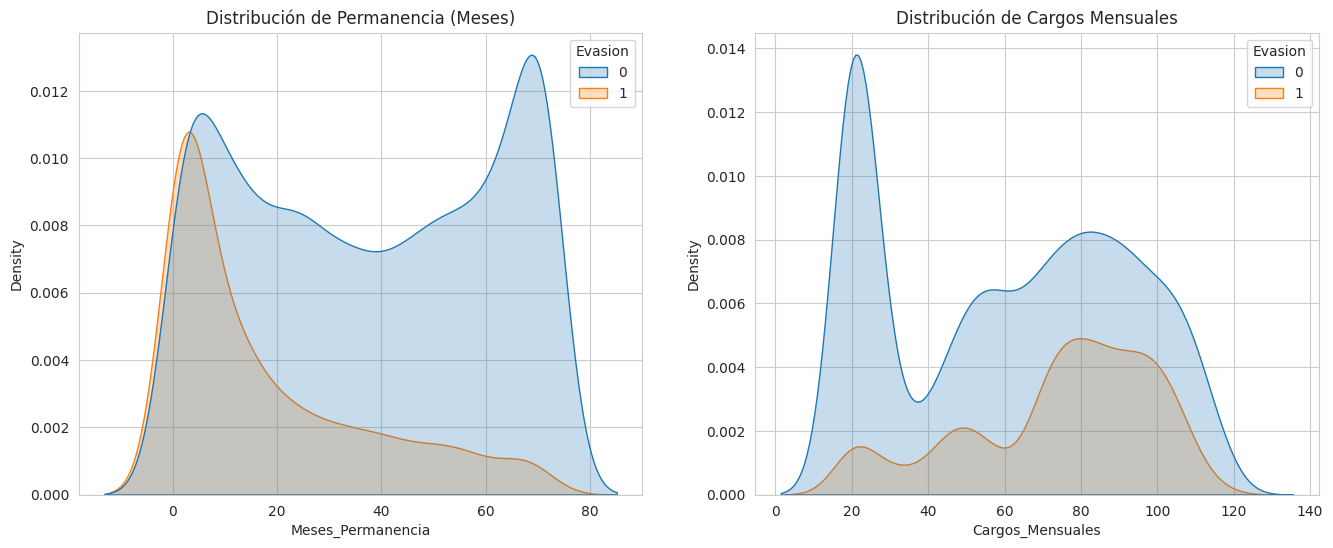

In [204]:
# Gráficos de Densidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_telecom, x='Meses_Permanencia', hue='Evasion', fill=True, ax=axes[0])
axes[0].set_title('Distribución de Permanencia (Meses)')

sns.kdeplot(data=df_telecom, x='Cargos_Mensuales', hue='Evasion', fill=True, ax=axes[1])
axes[1].set_title('Distribución de Cargos Mensuales')

plt.show()

####**Explicación:**

La fuga es mayor en los primeros 12 meses de contrato.

Los clientes que se van tienden a tener Cargos Mensuales más altos (pico entre $70 y $100), indicando sensibilidad al precio.

### **4. Conclusiones e Insights**

- El costo importa: Los clientes con facturas elevadas tienen mayor tendencia a la evasión.

- Lealtad temprana: Los clientes nuevos son los más volátiles; una vez superado el primer año, la probabilidad de fuga disminuye drásticamente.

- Falta de compromiso: Los contratos mensuales son la principal vía de escape de los clientes.

### **5. Recomendaciones Estratégicas**

- Migración de Contratos: Ofrecer descuentos exclusivos a clientes de "Mes a mes" para que cambien a contratos anuales.

- Alertas de Facturación: Monitorear a clientes cuyos cargos mensuales superen los $80, ofreciéndoles planes de beneficios para evitar que busquen competencia más barata.

- Automatización de Pagos: Incentivar el uso de pagos automáticos (tarjeta/banco) para reducir la tasa de cancelación asociada al cheque electrónico.

- Fidelización Temprana: Implementar campañas de "Satisfacción Garantizada" durante los primeros 6 meses del cliente.